<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Dataset_DataLoader_Pr%C3%A1tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
#dados simulados com 3 features de entrada e 1 saída
X = torch.randn(100, 3)
y = torch.randn(100, 1)

In [3]:
# Criando o Dataset e DataLoader
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [4]:
#arquitetrua da rede neural
class RegressaoNet(nn.Module):
    def __init__(self):
        super(RegressaoNet, self).__init__()
        self.layer1 = nn.Linear(3, 16)  # 3 entradas para 16 neurônios ocultos
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(16, 1)  # 16 neurônios para 1 saída

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

model = RegressaoNet()

In [13]:
#função de perda e otimizador
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [21]:
#loop de treinamento simulado
epoch = 10
historico_loss = []
model.train()
for batch_X, batch_y in dataloader:
    #zera os gradientes
    optimizer.zero_grad()
    #passagem para frente
    predictions = model(batch_X)
    #clcula o erro
    loss = criterion(predictions, batch_y)
    #retropropagação e otimização
    loss.backward()
    optimizer.step()
    running_loss = loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    historico_loss.append(epoch_loss)
    print(f"epoca [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

epoca [11/10], Loss: 0.0956
epoca [11/10], Loss: 0.0046
epoca [11/10], Loss: 0.0206
epoca [11/10], Loss: 0.0945
epoca [11/10], Loss: 0.0280
epoca [11/10], Loss: 0.0308
epoca [11/10], Loss: 0.0245
epoca [11/10], Loss: 0.0283
epoca [11/10], Loss: 0.0205
epoca [11/10], Loss: 0.1083
epoca [11/10], Loss: 0.0397
epoca [11/10], Loss: 0.0107
epoca [11/10], Loss: 0.0290
epoca [11/10], Loss: 0.0240
epoca [11/10], Loss: 0.0360
epoca [11/10], Loss: 0.0162
epoca [11/10], Loss: 0.1016
epoca [11/10], Loss: 0.0173
epoca [11/10], Loss: 0.0776
epoca [11/10], Loss: 0.0156
epoca [11/10], Loss: 0.0261
epoca [11/10], Loss: 0.0380
epoca [11/10], Loss: 0.0301
epoca [11/10], Loss: 0.0418
epoca [11/10], Loss: 0.1247


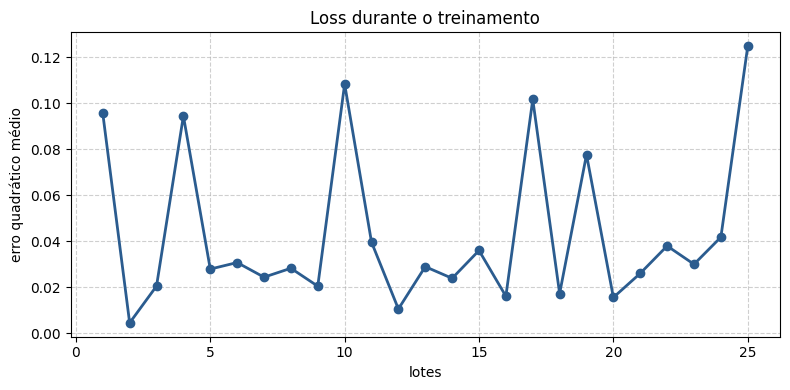

In [23]:
#evoluçao de perda
plt.figure(figsize=(8, 4))
# Ajustando o eixo X para corresponder ao número de perdas por lote
plt.plot(range(1, len(historico_loss) + 1), historico_loss, marker='o', linestyle='-', color='#2b5c8f', linewidth=2)
plt.title('Loss durante o treinamento')
plt.xlabel('lotes') # Mudando o rótulo do eixo X de 'epocas' para 'lotes'
plt.ylabel('erro quadrático médio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()